# Import library

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision.datasets import CIFAR10
from torchvision import transforms

from PIL import Image
import matplotlib.pyplot as plt


# Implement DDPM

## Lịch trình Nhiễu (Noise Scheduler)
Module này quản lý quá trình thêm nhiễu (Forward Process) và cung cấp các hệ số cho quá trình khử nhiễu (Reverse Process). Bạn cần khởi tạo và tính toán trước các tensor sau:

* **Tổng số bước ($T$):** Thường thiết lập là 1000.
* **Variance Schedule ($\beta_t$):** Mảng các giá trị tăng dần tuyến tính từ $\beta_1$ (ví dụ: 0.0001) đến $\beta_T$ (ví dụ: 0.02).
* **Các hằng số phái sinh:**
    * $\alpha_t = 1 - \beta_t$
    * $\bar{\alpha}_t = \prod_{i=1}^t \alpha_i = \exp\left(\sum_{i=1}^{t} \log \alpha_i\right)$ (Tích lũy của $\alpha_t$) 
    * $\sqrt{\bar{\alpha}_t}$ và $\sqrt{1 - \bar{\alpha}_t}$ (Dùng cho công thức Forward Process).

[Importance of Noise Schedule in Diffusion Process](https://www.analyticsvidhya.com/blog/2024/07/noise-schedules-in-stable-diffusion/)
### Linear schedule
β_t = β_start + (β_end – β_start) * (t / T)
Where:
- β_t is the noise level at step t
- β_start is the initial noise level (usually close to 0)
- β_end is the final noise level (usually close to 1)
- t is the current step
- T is the total number of steps

### Forward Process
![forward](../docs/forward_process.png)

### Reverse Process
![reverse](../docs/reverse_process.png)

In [3]:
def ddpm_schedules(beta1: float, beta2: float, T: int) -> dict[str, torch.Tensor]:
    """
    Pre-compute all diffusion schedules used in DDPM training and sampling.
    """

    assert beta1 < beta2 < 1.0, "beta1 and beta2 must be in (0, 1)"

    # Linear variance schedule:
    # beta_t increases linearly from beta1 to beta2
    # β_t = β_start + (β_end – β_start) * (t / T)
    beta_t = (
        (beta2 - beta1)
        * torch.arange(0, T + 1, dtype=torch.float32)
        / T
        + beta1
    )

    sqrt_beta_t = torch.sqrt(beta_t)

    # alpha_t = 1 - beta_t
    alpha_t = 1 - beta_t

    # Original implementation:
    # alphabar_t = torch.cumprod(alpha_t, dim=0)
    #
    # Problem:
    # Multiplying many values smaller than 1 may cause numerical underflow.
    #
    # Stable solution:
    # prod(x) = exp(sum(log(x)))
    log_alpha_t = torch.log(alpha_t)
    alphabar_t = torch.cumsum(log_alpha_t, dim=0).exp()

    # ============================================================
    # Forward diffusion process: q(x_t | x_0)
    # ============================================================

    # sqrt(alphabar_t)
    sqrtab = torch.sqrt(alphabar_t)

    # sqrt(1 - alphabar_t)
    sqrtmab = torch.sqrt(1 - alphabar_t)

    # ============================================================
    # Reverse diffusion process: p(x_{t-1} | x_t)
    # ============================================================

    # 1 / sqrt(alpha_t)
    oneover_sqrta = 1 / torch.sqrt(alpha_t)

    # (1 - alpha_t) / sqrt(1 - alphabar_t)
    mab_over_sqrtmab_inv = (1 - alpha_t) / sqrtmab

    return {
        "alpha_t": alpha_t,  # α_t
        "oneover_sqrta": oneover_sqrta,  # 1/sqrt(α_t)
        "sqrt_beta_t": sqrt_beta_t,  # sqrt(β_t)
        "alphabar_t": alphabar_t,  # ᾱ_t
        "sqrtab": sqrtab,  # sqrt(ᾱ_t)
        "sqrtmab": sqrtmab,  # sqrt(1 - ᾱ_t)
        "mab_over_sqrtmab": mab_over_sqrtmab_inv,  # (1-α_t)/sqrt(1-ᾱ_t)
    }

In [4]:
def q_sample(x_0, t, noise_schedule_dict, noise=None):
    """Add Gaussian noise to image x_0 at timestep t and return noisy image x_t."""

    # Generate random Gaussian noise if not provided
    if noise is None:
        noise = torch.randn_like(x_0)

    """
    Why do we use multiple `None` dimensions?
    -----------------------------------------
    Reason:
        - x_0 has shape [batch, channels, height, width]
          Example: [32, 3, 28, 28]

        - t has shape [batch]
          Example: [32]

        - Therefore:
            noise_schedule_dict["sqrtab"][t]
          returns a tensor with shape [32]

        - This causes a shape mismatch when multiplying with x_0.

    Solution:
        Add extra singleton dimensions using `None`
        (equivalent to unsqueeze).

        Example:
            [32] -> [32, 1, 1, 1]

        This enables broadcasting across channels, height, and width.
    """
    # sqrtab = noise_schedule_dict["sqrtab"][t].unsqueeze(1).unsqueeze(2).unsqueeze(3)
    # sqrtmab = noise_schedule_dict["sqrtmab"][t].unsqueeze(1).unsqueeze(2).unsqueeze(3)
    
    sqrtab = noise_schedule_dict["sqrtab"][t, None, None, None]
    sqrtmab = noise_schedule_dict["sqrtmab"][t, None, None, None]

    x_t = sqrtab * x_0 + sqrtmab * noise

    return x_t, noise

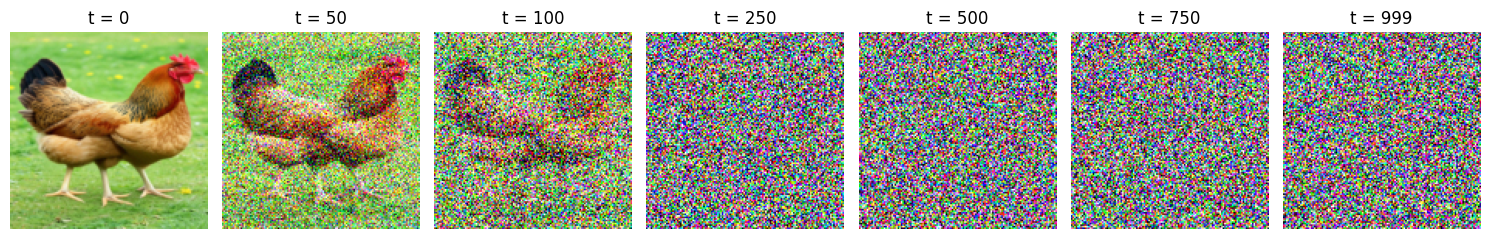

In [5]:
def run_forward():
    # ============================================================
    # Diffusion hyperparameters
    # ============================================================

    T = 1000
    betas = (1e-4, 0.2)

    # Pre-compute diffusion schedules
    schedules = ddpm_schedules(betas[0], betas[1], T)

    # ============================================================
    # Load image
    # ============================================================

    image = Image.open(
        "/home/anhndt/latent-diffusion-from-scratch/data/example.png"
    ).convert("RGB")

    # ============================================================
    # Image preprocessing
    # ============================================================

    transform = transforms.Compose([
        transforms.Resize((128, 128)),   # Resize image
        transforms.ToTensor(),           # Convert to tensor in range [0, 1]

        # Normalize to range [-1, 1]
        # Important for diffusion models
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])

    # Add batch dimension:
    # [C, H, W] -> [1, C, H, W]
    x_0 = transform(image).unsqueeze(0)

    # Timesteps to visualize
    timesteps = [0, 50, 100, 250, 500, 750, 999]

    # Create matplotlib figure
    fig, axes = plt.subplots(1, len(timesteps), figsize=(15, 3))

    # ============================================================
    # Forward diffusion visualization
    # ============================================================

    for i, t_val in enumerate(timesteps):

        # Create timestep tensor
        t = torch.tensor([t_val])

        # Add Gaussian noise
        x_t, _ = q_sample(x_0, t, schedules)

        # ========================================================
        # Convert image back for visualization
        # ========================================================

        # Denormalize:
        # [-1, 1] -> [0, 1]
        img_display = (x_t.squeeze(0) + 1.0) / 2.0

        # Clamp to valid image range
        img_display = torch.clamp(img_display, 0.0, 1.0)

        # Convert:
        # [C, H, W] -> [H, W, C]
        # for matplotlib
        img_display = img_display.permute(1, 2, 0).numpy()

        # ========================================================
        # Plot image
        # ========================================================

        axes[i].imshow(img_display)
        axes[i].set_title(f"t = {t_val}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()


run_forward()

In [6]:
class DDPM(nn.Module):
    def __init__(self, 
                 eps_model: nn.Module, 
                 betas: tuple[float, float], 
                 n_T: int, 
                 criterion: nn.Module = nn.MSELoss()
                 ) -> None:
        super(DDPM, self).__init__()
        self.eps_model = eps_model

        self.schedules = ddpm_schedules(betas[0], betas[1], n_T)

        for k, v in self.schedules.items():
            self.register_buffer(k, v)
        """
        Tại sao phải sử dụng register_buffer?
        ------------------------------------
        Lý do 1: Tự động đồng bộ Device (CPU <-> GPU).
        Khi đưa model lên GPU `model.to(cuda)`. Nếu không có register_buffer thì 

        """
        self.n_T = n_T
        self.criterion = criterion
    def forward(self, x):
        _ts = torch.randint(1, self.n_T + 1, (x.shape[0], )).to(x.device)
        eps = torch.randn_like(x)

        x_t, _ = q_sample(x, _ts, self.schedules, eps)

        predicted_eps = self.eps_model(x_t, _ts / self.n_T)

        return self.criterion(eps, predicted_eps)
    
    def sample(self, n_sample: int, size, device) -> torch.Tensor:

        x_i = torch.randn(n_sample, *size).to(device)  # x_T ~ N(0, 1)

        # This samples accordingly to Algorithm 2. It is exactly the same logic.
        for i in range(self.n_T, 0, -1):
            z = torch.randn(n_sample, *size).to(device) if i > 1 else 0
            eps = self.eps_model(
                x_i, torch.tensor(i / self.n_T).to(device).repeat(n_sample, 1)
            )
            x_i = (
                self.oneover_sqrta[i] * (x_i - eps * self.mab_over_sqrtmab[i])
                + self.sqrt_beta_t[i] * z
            )

        return x_i

## DENOISING DIFFUSION IMPLICIT MODELS

![ddim](/home/anhndt/latent-diffusion-from-scratch/docs/ddim.png)

- $\sigma_t = \eta \sqrt{\frac{1 - \bar{\alpha}_{t-1}}{1 - \bar{\alpha}_t}} \sqrt{1 - \frac{\bar{\alpha}_t}{\bar{\alpha}_{t-1}}}$

- Nếu $\eta = 1$: Thuật toán DDIM này toán học tương đương chính xác với DDPM (có thêm nhiễu ngẫu nhiên ở mỗi bước).
- Nếu $\eta = 0$: Đây là sức mạnh thực sự của DDIM. Quá trình khử nhiễu trở nên **hoàn toàn tất định (deterministic)**. Không có hạt nhiễu $z$ nào được bơm thêm vào. Cùng một tensor nhiễu ban đầu $x_T$, bạn sẽ luôn sinh ra chính xác cùng một bức ảnh $x_0$. Điều này cho phép bạn thực hiện phép nội suy (interpolation) trong không gian latent rất mượt mà.

In [7]:
class DDIM(DDPM):
    def __init__(self, 
                 eps_model: nn.Module, 
                 betas: tuple[float, float], 
                 n_T: int, 
                 criterion: nn.Module = nn.MSELoss(), 
                 eta: float = 0.0
                 ) -> None:
        super(DDIM, self).__init__(eps_model, betas, n_T, criterion)
        self.eta = eta

    def sample(self, n_sample: int, size, device) -> torch.Tensor:

        x_i = torch.randn(n_sample, *size).to(device)  # x_T ~ N(0, 1)

        for i in range(self.n_T, 0, -1):
            z = torch.randn(n_sample, *size).to(device) if i > 1 else 0
            eps = self.eps_model(
                x_i, torch.tensor(i / self.n_T).to(device).repeat(n_sample, 1)
            )
            # predicted x_0
            x0_t = (x_i - eps * (1 - self.alphabar_t[i]).sqrt()) / self.alphabar_t[i].sqrt()

            # direction pointing to x_i
            c1 = self.eta * ((1 - self.alphabar_t[i] / self.alphabar_t[i - 1]) * (1 - self.alphabar_t[i - 1]) / (
                    1 - self.alphabar_t[i])).sqrt()
            
            # random noise to add
            c2 = ((1 - self.alphabar_t[i - 1]) - c1 ** 2).sqrt()

            x_i = self.alphabar_t[i - 1].sqrt() * x0_t + c1 * z + c2 * eps

        return x_i